In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdoc-dataset' dataset.
Path to dataset files: /kaggle/input/plantdoc-dataset


In [ ]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory ({path}):\n{os.listdir(path)}")

# Assuming 'Train' is one of the subdirectories, let's list its contents to see the classes
try:
    train_data_path = os.path.join(path, 'Train')
    print(f"\nContents of the 'Train' directory ({train_data_path}):\n{os.listdir(train_data_path)}")
except FileNotFoundError:
    print(f"\n'Train' directory not found at {train_data_path}. Please verify the dataset structure.")

Contents of the dataset directory (/kaggle/input/plantdoc-dataset):
['folder_renamer.py', 'file_renamer.py', 'test', 'train']

'Train' directory not found at /kaggle/input/plantdoc-dataset/Train. Please verify the dataset structure.


### Check GPU Activity
First, let's check if a GPU is available and being used by TensorFlow.

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus}")
    # Optionally, you can set memory growth to avoid allocating all GPU memory at once
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. Training will run on CPU.")

GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPUs


### Load and Preprocess the Dataset

Now, we'll load the image dataset downloaded from KaggleHub. We'll use `tf.keras.utils.image_dataset_from_directory` to create datasets for training, validation, and testing. We'll also define some preprocessing steps, such as resizing images and creating batches.

In [ ]:
import os

# The dataset structure for 'plantdoc-dataset' is directly path/train and path/test
# We will create a validation split from the training data.

train_data_root = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

# Define image parameters
IMG_HEIGHT = 224 # MobileNetV2 expects at least 32x32, 224x224 is common
IMG_WIDTH = 224
BATCH_SIZE = 32

# Create training dataset (with validation split)
# Use a fixed seed for reproducibility of the split
SEED = 123
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_root,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)

# Create validation dataset from the same training data root
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_root,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)

# Create test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get class names
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Found {NUM_CLASSES} classes: {class_names}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data augmentation layer (optional, can be added to the model directly)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

# Preprocessing for MobileNetV2: Scale pixels to the range [-1, 1]
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

Found 2670 files belonging to 28 classes.
Using 2136 files for training.
Found 2670 files belonging to 28 classes.
Using 534 files for validation.
Found 252 files belonging to 27 classes.
Found 28 classes: ['Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Bell_pepper_leaf', 'Bell_pepper_leaf_spot', 'Blueberry_leaf', 'Cherry_leaf', 'Corn_Gray_leaf_spot', 'Corn_leaf_blight', 'Corn_rust_leaf', 'Peach_leaf', 'Potato_leaf_early_blight', 'Potato_leaf_late_blight', 'Raspberry_leaf', 'Soyabean_leaf', 'Squash_Powdery_mildew_leaf', 'Strawberry_leaf', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_spot', 'Tomato_leaf', 'Tomato_leaf_bacterial_spot', 'Tomato_leaf_late_blight', 'Tomato_leaf_mosaic_virus', 'Tomato_leaf_yellow_virus', 'Tomato_mold_leaf', 'Tomato_two_spotted_spider_mites_leaf', 'grape_leaf', 'grape_leaf_black_rot']


In [ ]:
import os

# The previous 'base_data_dir' variable is now incorrect for the new dataset.
# Let's inspect the contents of the main downloaded path and the 'train' data root.

print(f"Contents of the main downloaded path ({path}):\n{os.listdir(path)}")

# Now, let's inspect the 'train_data_root' which was correctly identified in cell 52957418.
try:
    if os.path.exists(train_data_root):
        print(f"\nContents of 'train_data_root' ({train_data_root}):\n{os.listdir(train_data_root)[:5]}...") # Print first 5 items
    else:
        print(f"\n'train_data_root' directory does not exist at {train_data_root}.")
except Exception as e:
    print(f"Error checking 'train_data_root' directory: {e}")

# Also check the test_dir
try:
    if os.path.exists(test_dir):
        print(f"\nContents of 'test_dir' ({test_dir}):\n{os.listdir(test_dir)[:5]}...") # Print first 5 items
    else:
        print(f"\n'test_dir' directory does not exist at {test_dir}.")
except Exception as e:
    print(f"Error checking 'test_dir' directory: {e}")

Contents of the main downloaded path (/kaggle/input/plantdoc-dataset):
['folder_renamer.py', 'file_renamer.py', 'test', 'train']

Contents of 'train_data_root' (/kaggle/input/plantdoc-dataset/train):
['Tomato_leaf_yellow_virus', 'Tomato_leaf_late_blight', 'Apple_Scab_Leaf', 'Cherry_leaf', 'grape_leaf']...

Contents of 'test_dir' (/kaggle/input/plantdoc-dataset/test):
['Tomato_leaf_yellow_virus', 'Tomato_leaf_late_blight', 'Apple_Scab_Leaf', 'Cherry_leaf', 'grape_leaf']...


### Build the MobileNet Model

We will use a pre-trained MobileNetV2 model as a base and add a custom classification head on top for our specific traffic sign dataset. This is a common practice known as transfer learning.

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Create the base model from the pre-trained MobileNetV2
# Exclude the top classification layer
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Create the classification head
global_average_layer = layers.GlobalAveragePooling2D()
prediction_layer = layers.Dense(NUM_CLASSES, activation='softmax')

# Build the full model
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs) # Apply data augmentation
x = preprocess_input(x)     # Preprocess for MobileNetV2
x = base_model(x, training=False)
x = global_average_layer(x)
x = layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = models.Model(inputs, outputs)

# Compile the model
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │        35,868 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,293,852 (8.75 MB)

 Trainable params: 35,868 (140.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Train the Model

Now, let's train the MobileNetV2 model on our dataset. The training will automatically use the GPU if it's available and configured correctly by TensorFlow.

In [ ]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 163ms/step - accuracy: 0.0641 - loss: 3.6191 - val_accuracy: 0.0974 - val_loss: 3.4880
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.1259 - loss: 3.2011 - val_accuracy: 0.1816 - val_loss: 3.2026
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.1845 - loss: 2.9425 - val_accuracy: 0.2528 - val_loss: 2.9699
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.2247 - loss: 2.7641 - val_accuracy: 0.2828 - val_loss: 2.7855
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2687 - loss: 2.5903 - val_accuracy: 0.3165 - val_loss: 2.6400
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.3090 - loss: 2.4609 - val_accuracy: 0.3502 - val_loss: 2.4944
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.3244 - loss: 2.3502 - val_accuracy: 0.3764 - val_loss: 2.3890
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.3567 - loss: 2.2338 - val_accuracy: 0.3876 -

### Summarize Training Results

This cell will provide a summary of the training process, including final accuracy and loss on the test set, and potentially other metrics if you configured them during compilation.

In [ ]:
import pandas as pd

print("\n--- Training Summary ---")
print(f"Epochs trained: {len(history.epoch)}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Test Loss: {loss:.4f}")

# Convert history to DataFrame for better readability (optional)
history_df = pd.DataFrame(history.history)
print("\nTraining History:")
display(history_df.tail())


--- Training Summary ---
Epochs trained: 10
Final Training Accuracy: 0.3886
Final Validation Accuracy: 0.4476
Final Test Accuracy: 0.3571
Final Training Loss: 2.0807
Final Validation Loss: 2.0884
Final Test Loss: 2.4863

Training History:


,accuracy,loss,val_accuracy,val_loss
5,0.308989,2.460918,0.350187,2.494447
6,0.324438,2.350211,0.376404,2.388955
7,0.356742,2.233756,0.387640,2.304291
8,0.362828,2.164525,0.411985,2.223913
9,0.388577,2.080715,0.447566,2.088431


### Display Training Plots

Let's visualize the training and validation accuracy and loss over the epochs to understand the model's learning progress and identify potential overfitting or underfitting.

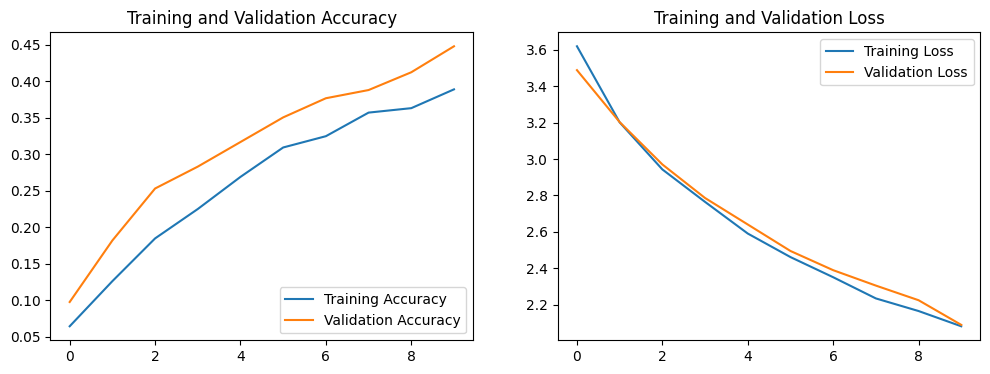

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()